In [105]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [106]:
data = pd.read_excel('../../data/project/Umamusume ML.xlsx')
data.head(15)

,score,letter,SPD,STA,PWR,GUTS,WIT,ult_lvl,inherited_ult,G1_wins,...,green_skills,skills_sprint,skills_mile,skills_medium,skills_long,skills_front,skills_pace,skills_late,skills_end,skills_universal
0,19699,Ug,1200,935,1167,989,799,4,-,18,...,6.0,1.0,0.0,0.0,0.0,0.0,6.0,0.0,0,9
1,19684,Ug,1196,910,1179,504,1110,5,seiun,17,...,7.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0,8
2,21721,Ug,1200,774,1200,758,1200,6,opera_skin,23,...,4.0,0.0,4.0,0.0,0.0,0.0,8.0,0.0,0,11
3,20520,Ug,1200,883,1200,646,1187,5,opera_skin. seiun,18,...,1.0,0.0,0.0,3.0,0.0,5.0,0.0,0.0,0,9
4,20958,Ug,1200,699,1177,695,1200,6,dober,20,...,3.0,0.0,5.0,0.0,0.0,0.0,0.0,6.0,0,10
5,19460,SS+,1046,1046,1184,749,830,5,-,18,...,3.0,0.0,5.5,0.0,0.0,0.0,0.0,5.5,0,4
6,19505,SS+,1200,574,1200,601,1200,6,dober,16,...,1.0,2.0,0.0,0.0,0.0,0.0,0.0,7.0,0,10
7,19245,SS+,1200,1014,966,795,856,5,seiun,20,...,5.0,0.0,0.0,6.0,0.0,5.0,0.0,0.0,0,6
8,19474,SS+,1200,1140,957,653,1057,5,kitasan,20,...,2.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,0,8
9,19587,SS+,1198,851,1026,951,935,5,-,23,...,3.0,0.0,5.0,0.0,0.0,0.0,6.0,0.0,0,10


In [107]:
letters = set(data['letter'].tolist())
letters_count = []
for letter in letters:
    letters_count.append([letter, 0])
indexes_for_mask = []
letters_count = []

In [108]:
for index, row in data.iterrows():
    current_letter = row['letter']
    if letters_count.count(current_letter) >= 2:
        continue
    else:
        letters_count.append(current_letter)
        indexes_for_mask.append(index)
    '''for e in letters_count:
        if current_letter == e[0]:
            current_count = e[1]
        else:
            continue
    if current_count < 2:
        indexes_for_mask.append(index)
        '''

In [109]:
mask = np.zeros(data.shape[0], dtype=int)
for i in indexes_for_mask:
    mask[i] = 1
mask = mask.astype(bool)

In [110]:
data.drop('letter', axis=1, inplace=True)

In [111]:
def ultifier(string):
    if string == '-':
        to_return = 0
    else:
        words = [w.strip() for w in str(string).split('.') if w.strip()]
        to_return = len(words)
    return to_return

In [112]:
apt_map = {
    "S": 8,
    "A": 7,
    "B": 6,
    "C": 5,
    "D": 4,
    "E": 3,
    "F": 2,
    "G": 1,
}
aptitudes = []
for col in data.columns:
    if 'apt' in col:
        aptitudes.append(col)
for apt in aptitudes:
    data[apt] = data[apt].map(apt_map)

In [113]:
udata = data.copy()

In [114]:
udata['inherited_ult'] = data['inherited_ult'].copy().apply(ultifier)

In [115]:
udata.head(15)

,score,SPD,STA,PWR,GUTS,WIT,ult_lvl,inherited_ult,G1_wins,G1_prize,...,green_skills,skills_sprint,skills_mile,skills_medium,skills_long,skills_front,skills_pace,skills_late,skills_end,skills_universal
0,19699,1200,935,1167,989,799,4,0,18,0,...,6.0,1.0,0.0,0.0,0.0,0.0,6.0,0.0,0,9
1,19684,1196,910,1179,504,1110,5,1,17,0,...,7.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0,8
2,21721,1200,774,1200,758,1200,6,1,23,0,...,4.0,0.0,4.0,0.0,0.0,0.0,8.0,0.0,0,11
3,20520,1200,883,1200,646,1187,5,2,18,0,...,1.0,0.0,0.0,3.0,0.0,5.0,0.0,0.0,0,9
4,20958,1200,699,1177,695,1200,6,1,20,0,...,3.0,0.0,5.0,0.0,0.0,0.0,0.0,6.0,0,10
5,19460,1046,1046,1184,749,830,5,0,18,0,...,3.0,0.0,5.5,0.0,0.0,0.0,0.0,5.5,0,4
6,19505,1200,574,1200,601,1200,6,1,16,0,...,1.0,2.0,0.0,0.0,0.0,0.0,0.0,7.0,0,10
7,19245,1200,1014,966,795,856,5,1,20,0,...,5.0,0.0,0.0,6.0,0.0,5.0,0.0,0.0,0,6
8,19474,1200,1140,957,653,1057,5,1,20,0,...,2.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,0,8
9,19587,1198,851,1026,951,935,5,0,23,0,...,3.0,0.0,5.0,0.0,0.0,0.0,6.0,0.0,0,10


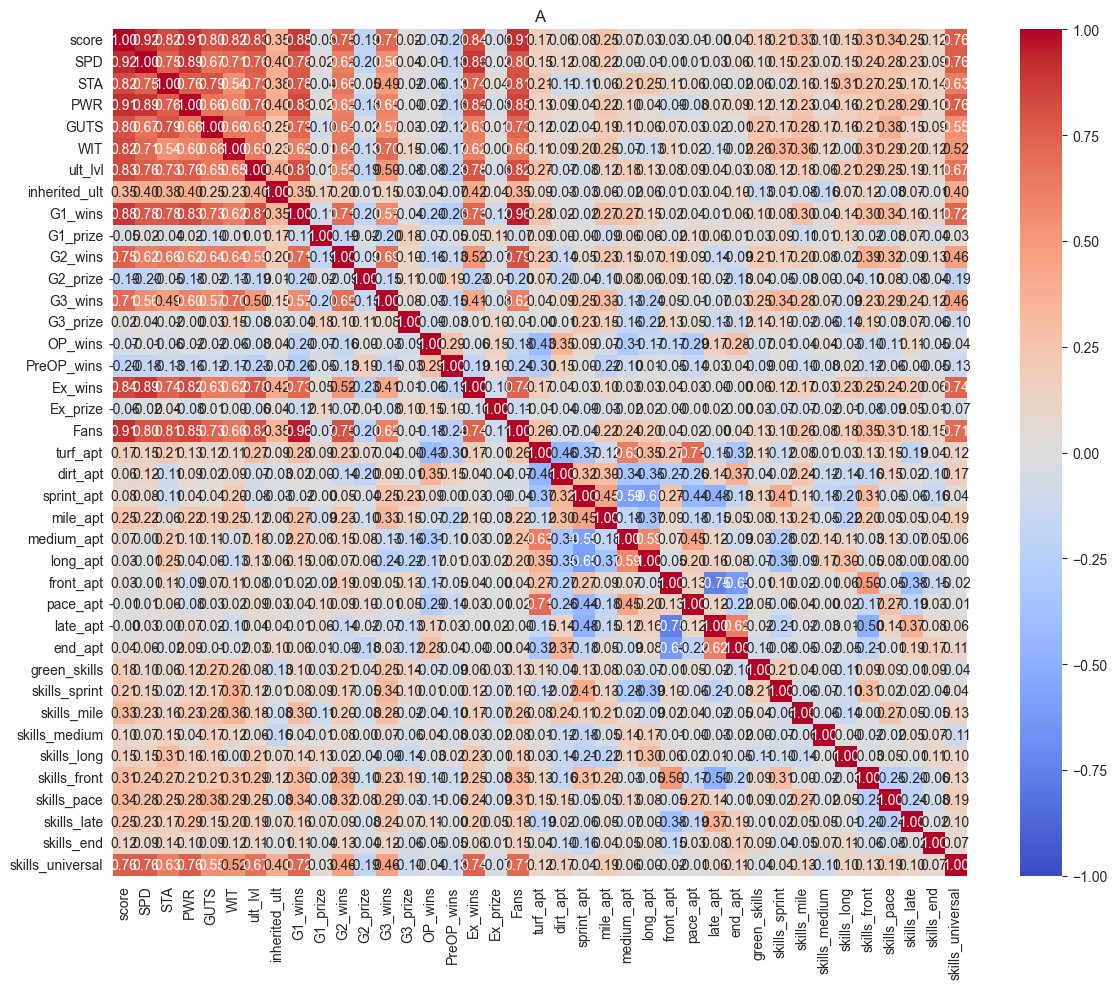

In [117]:
corr_matrix = udata.corr()
plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('A')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
train_df = data[~mask]
test_df = data[mask]